<div style="padding:22px 26px;border-left:6px solid #0b7285;background:linear-gradient(90deg,#e6fcf5,#f8f9fa);border-radius:8px;">
  <h1 style="margin:0;color:#0b3d4a;">Guía de Laboratorio 01</h1>
  <p style="margin:8px 0 0;color:#495057;font-size:1.08em;">Fundamentos de análisis de datos con Python</p>
</div>

| Estudiante | Materia | Fecha |
|:--|:--|:--|
| **Abdair Coca** | **INF672** | **11 de agosto de 2026** |

> Objetivo: construir un flujo breve, reproducible y visual usando NumPy, Pandas y Matplotlib.

## Modelo: regresión lineal

Para describir la relación entre una variable explicativa $x$ y una respuesta $y$, usamos:

$$
\hat{y}_i = \beta_0 + \beta_1 x_i
$$

Los coeficientes se estiman minimizando el error cuadrático:

$$
\min_{\beta_0,\beta_1}\; \sum_{i=1}^{n}\left(y_i-\hat{y}_i\right)^2
$$

El ajuste se evaluará con $R^2$: cuanto más cercano a 1, mayor proporción de variabilidad explica el modelo.

In [1]:
print("LABORATORIO INF672 · PYTHON PARA ANÁLISIS DE DATOS")
print("Estudiante: Abdair Coca")
print("Flujo listo: NumPy → Pandas → Matplotlib")

LABORATORIO INF672 · PYTHON PARA ANÁLISIS DE DATOS
Estudiante: Abdair Coca
Flujo listo: NumPy → Pandas → Matplotlib


In [2]:
import numpy as np

# Datos reproducibles: horas de estudio y calificación
x = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=float)
y = np.array([52, 57, 61, 68, 72, 78, 83, 88], dtype=float)

beta_1, beta_0 = np.polyfit(x, y, 1)
y_hat = beta_0 + beta_1 * x
r2 = 1 - np.sum((y - y_hat) ** 2) / np.sum((y - y.mean()) ** 2)

print(f"Modelo estimado: ŷ = {beta_0:.2f} + {beta_1:.2f}x")
print(f"Coeficiente de determinación: R² = {r2:.4f}")

Modelo estimado: ŷ = 46.46 + 5.20x
Coeficiente de determinación: R² = 0.9981


In [3]:
import pandas as pd

df = pd.DataFrame({
    "Horas de estudio": x.astype(int),
    "Calificación real": y.astype(int),
    "Predicción": y_hat,
})
df["Residuo"] = df["Calificación real"] - df["Predicción"]

df.round(2)

,Horas de estudio,Calificación real,Predicción,Residuo
0,1,52,51.67,0.33
1,2,57,56.87,0.13
2,3,61,62.07,-1.07
3,4,68,67.27,0.73
4,5,72,72.48,-0.48
5,6,78,77.68,0.32
6,7,83,82.88,0.12
7,8,88,88.08,-0.08


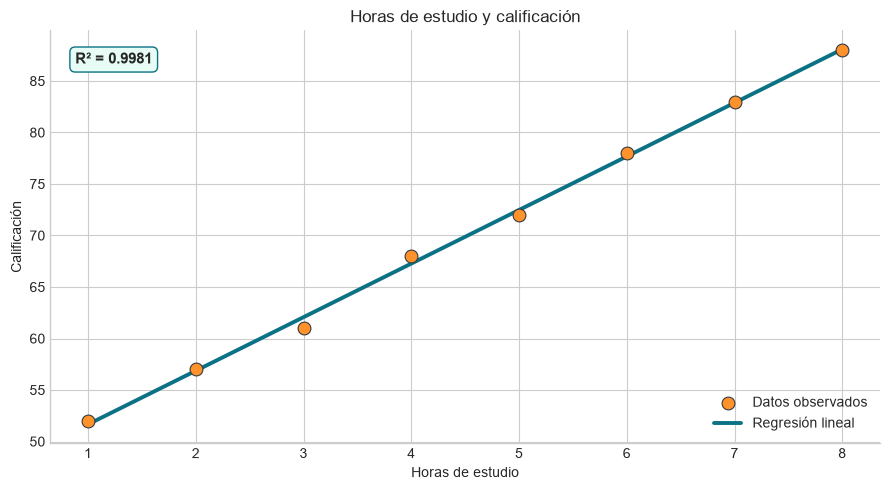

In [4]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(
    x, y, s=85, color="#ff922b", edgecolor="#343a40",
    linewidth=0.8, label="Datos observados", zorder=3
)
ax.plot(
    x, y_hat, color="#0b7285", linewidth=2.8,
    label="Regresión lineal", zorder=2
)

ax.set(
    title="Horas de estudio y calificación",
    xlabel="Horas de estudio",
    ylabel="Calificación",
)
ax.text(
    0.03, 0.92, f"R² = {r2:.4f}",
    transform=ax.transAxes, fontsize=11, weight="bold",
    bbox={"boxstyle": "round,pad=0.35", "facecolor": "#e6fcf5", "edgecolor": "#0b7285"},
)
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## Evidencia del entorno

La salida de `conda env list` confirma que el entorno **INF672** está activo:

<img src="captura_conda_env_inf672.png" alt="Terminal con la salida de conda env list y el entorno INF672 activo" style="width:100%;max-width:980px;border:1px solid #dee2e6;border-radius:8px;">